# Getting started with TorchHerd

**TorchHerd** is a differentiable PyTorch framework for livestock population modelling. This notebook walks through:

1. Running a one-year cattle simulation with a single call.
2. Plotting the age/sex-structured population dynamics.
3. Looking at whole-farm outputs (methane, manure).
4. Using autograd to get gradients of a herd output with respect to a model parameter — the basis for calibration.


In [1]:
import torch
import matplotlib.pyplot as plt

import torchherd
from torchherd import LivestockModel, run_simulation

print('torchherd', torchherd.__version__)

torchherd 0.0.1


## 1. Run a simulation

`run_simulation` drives the composed `LivestockModel` forward under a constant daily forcing and returns one record (a plain dictionary of floats) per simulated day.

In [2]:
records = run_simulation(animal='Cattle', activity='Stall', days=365)

print('days simulated :', len(records))
print('start animals  :', round(records[0]['total_animals'], 1))
print('final animals  :', round(records[-1]['total_animals'], 1))
records[-1]

days simulated : 365
start animals  : 59975.9
final animals  : 52030.1


{'day': 365,
 'total_animals': 52030.14519193626,
 'juvenile_female': 7575.942503803889,
 'subadult_female': 9028.158585320345,
 'adult_female': 9410.971506843895,
 'juvenile_male': 7575.942503803889,
 'subadult_male': 9028.158585320345,
 'adult_male': 9410.971506843895,
 'milk_produced': 1740385.1416766108,
 'milk_exported': -10381122.864409612,
 'ch4_emission': 6771.293649685169,
 'manure_storage': 2416303.564564511,
 'sum_meat': 4139075141.920861}

## 2. Population dynamics

The herd is tracked in six age/sex classes. Here is how each class evolves over the year.

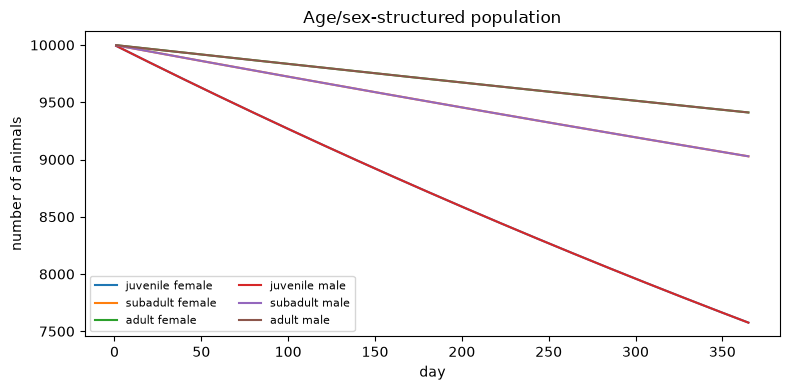

In [3]:
days = [r['day'] for r in records]
classes = [
    'juvenile_female', 'subadult_female', 'adult_female',
    'juvenile_male', 'subadult_male', 'adult_male',
]

fig, ax = plt.subplots(figsize=(8, 4))
for c in classes:
    ax.plot(days, [r[c] for r in records], label=c.replace('_', ' '))
ax.set_xlabel('day')
ax.set_ylabel('number of animals')
ax.set_title('Age/sex-structured population')
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()

## 3. Whole-farm outputs

Alongside the population, each step reports production and environmental variables. Below: daily enteric methane emission and the manure in store.

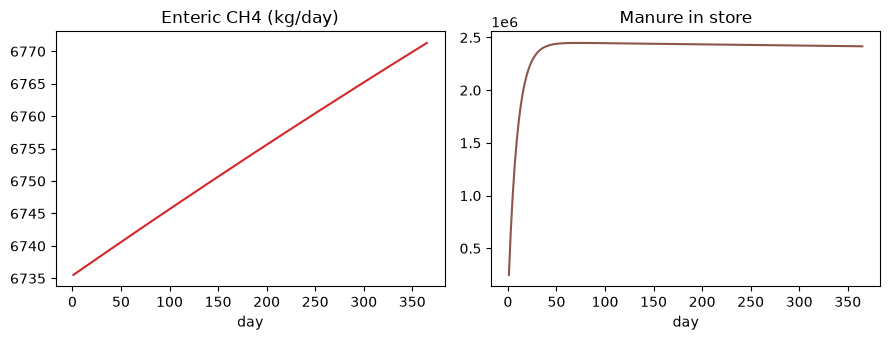

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3.5))
a1.plot(days, [r['ch4_emission'] for r in records], color='tab:red')
a1.set_title('Enteric CH4 (kg/day)')
a1.set_xlabel('day')
a2.plot(days, [r['manure_storage'] for r in records], color='tab:brown')
a2.set_title('Manure in store')
a2.set_xlabel('day')
fig.tight_layout()

## 4. Differentiability

Every component is a `torch.nn.Module`, so a whole simulation is one big differentiable function. We can therefore ask: *how sensitive is the final herd size to a parameter?* — by building a trainable model, running a few steps, and calling `.backward()`.

The same mechanism lets you **calibrate** parameters against observations with any `torch.optim` optimiser (see the Usage page).

In [5]:
model = LivestockModel(animal='Cattle', activity='Stall', trainable=True)
model.reset_state()

def f(x):
    return torch.tensor(float(x), dtype=torch.float64)

forcing = dict(
    iMilkAmount=f(1000.0),
    iForageProduction=f(2.0e10),
    iConcentrateProduction=f(5.0e9),
    iFodderProduction=f(5.0e6),
    iFertilizeFraction=f(0.1),
    iDroppingFraction=f(0.2),
)

for _ in range(15):
    out = model.step(**forcing)

out['population']['sTotalAnimals'].backward()
grad = float(model.population.cAdultFemaleMortalityFraction.grad)
print('d(total animals) / d(adult-female mortality) =', round(grad, 1))

d(total animals) / d(adult-female mortality) = -842.5


The gradient is negative: increasing adult-female mortality reduces the total herd size after 15 days — exactly the direction we would expect. Feeding this gradient to an optimiser is all it takes to fit the parameter to data.

## Next steps

- See the [Usage](../usage.md) page for the step-by-step API and a full calibration loop.
- Browse the [API reference](../torchherd.md) for every component and its parameters.